## CodeAlpha Data Visualization and Business Insights

## 1. Project Introduction

This project focuses on transforming business data into meaningful and informative visualizations using Python. The analysis uses charts and graphs to explore sales performance, customer segments, product performance, regional trends, profitability, and other key business metrics. The visualizations are designed to identify patterns and trends clearly and communicate data-driven insights that can support better business decision-making.


## 2. Project Objective

The main objective of this project is to analyze and visualize business data using Python visualization libraries such as Matplotlib and Seaborn. The project aims to:

* Transform raw data into clear and meaningful visualizations.
* Identify important trends and patterns in sales and business performance.
* Compare products, categories, customer segments, and regions.
* Analyze profitability and other key business metrics.
* Present observations and business insights from the visualizations.
* Communicate findings in a clear and understandable manner to support data-driven decision-making.


## 3. Dataset Description

The dataset used in this project contains business-related sales transaction data. It includes information about products, sales, profit, discounts, customer segments, regions, and order dates. The dataset provides sufficient information to analyze sales performance, product and regional trends, customer contributions, and profitability through different types of visualizations.

The dataset is used to create meaningful charts and identify patterns and business insights from the available data.


## 4. Tools and Libraries

* Python
* Pandas
* Matplotlib
* Seaborn
* Jupyter Notebook


## 5. Business Questions

Q1. How does sales performance vary across regions?

Q2. Which customer segments contribute most to sales?

Q3. Which products contribute most to overall revenue?

Q4. How does sales performance change month by month?

Q5. Which categories generate the highest profit margins?

Q6. Which regions have high sales but comparatively low profit?

Q7. How does average discount vary across product categories?

Q8. Which customer segments generate the highest profit?

##  6. Data Visualization and Analysis

The following visualizations are created to explore different aspects of the dataset and identify meaningful patterns, trends, and business insights.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df= pd.read_csv('Sample-Superstore.1.csv')

In [18]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Products,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [19]:
df.shape

(9994, 20)

# Question 1: How does sales performance vary across different regions?

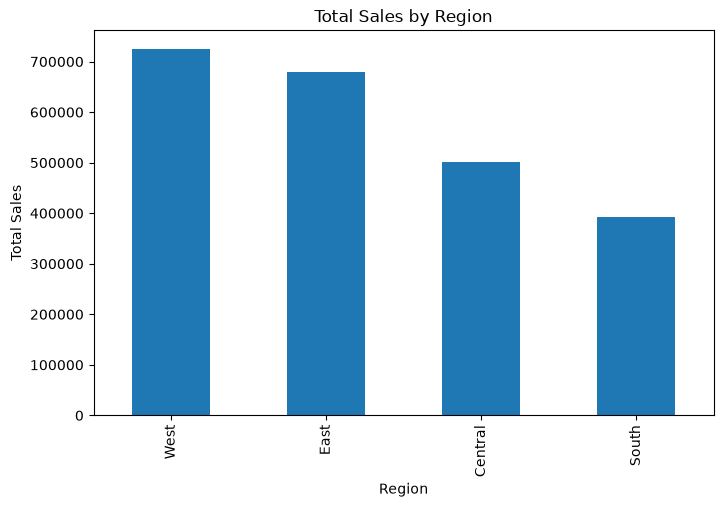

In [20]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

region_sales.plot(kind='bar', figsize=(8,5))

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()

### Observation
The West region recorded the highest total sales at approximately 725,000, followed by the East region with approximately 680,000. The Central and South regions recorded comparatively lower sales, at around 500,000 and 390,000, respectively.

### Business Insights
The West and East regions are the strongest contributors to total sales, while the South region has comparatively lower sales. This suggests that the business could examine the factors contributing to the stronger performance of the West and East regions and explore opportunities to improve sales in lower-performing regions.

## Question 2: Which customer segments contribute most to sales?

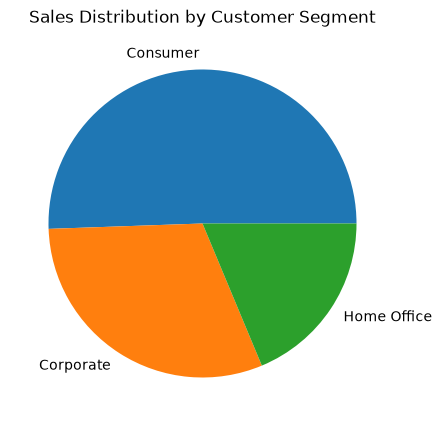

In [21]:
segment_sales= df.groupby('Segment')['Sales'].sum()
segment_sales.plot(kind='pie', figsize=(8,5))
plt.title('Sales Distribution by Customer Segment')
plt.ylabel('')
plt.show()

## Observations 
Consumer represents the largest market segment, contributing 50.5% of total sales distribution. Corporate forms the second-largest share at 30.5%. Home Office accounts for the remaining 19% of sales.   

## Business Insights
Sales are heavily driven by the Consumer and Corporate segments, which together generate 81% of total revenue. With Consumers accounting for over half of all sales (50.5%), resource allocation and marketing strategies should prioritize consumer retention and demand planning. Simultaneously, the Home Office segment (19%) represents a secondary niche that can be targeted for incremental market share growth without shifting focus from the core business.   

## Question 3: Which products contribute most to overall revenue?

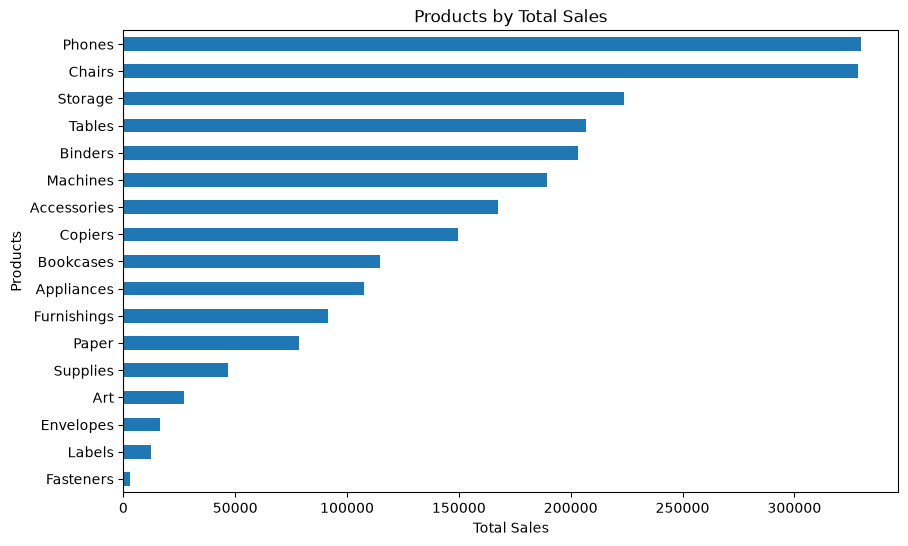

In [22]:
products_sales = df.groupby('Products')['Sales'].sum().sort_values(ascending=False)
products_sales.sort_values().plot( kind='barh', figsize=(10, 6))
plt.title('Products by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Products')
plt.show()

### Observation
Phones and Chairs are the leading products at approximately 330K each. Storage, Tables, Binders, and Machines generate 180K–225K. Fasteners, Labels, and Envelopes contribute the least, with Fasteners below 5K.

### Business Insights
Sales revenue is concentrated among several high-performing technology and furniture products, led by Phones and Chairs. Resource allocation and supply chain management should prioritize maintaining stock levels and driving demand for these top-performing products. Meanwhile, Low-sales products such as Fasteners and Labels contribute relatively little to overall revenue and could be considered for cross-selling or bundling strategies.

### Question 4: How does sales performance change month by month?


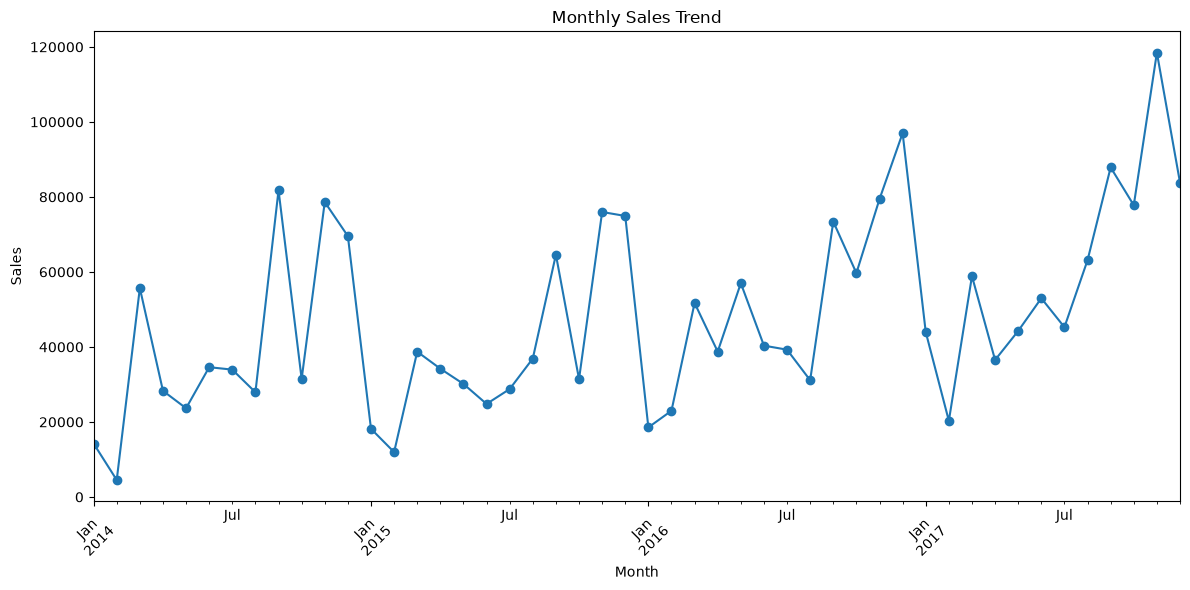

In [23]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly_sales = (df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum())


monthly_sales.plot(kind='line', marker='o', figsize=(12,6))

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observation
Monthly sales show significant fluctuations, with several sharp peaks and declines. The overall sales level shows improvement in the later years,particularly from 2016 onward. A monthly sales peak of approximately 118K occurs in 2017. The recurring peaks and declines suggest possible seasonal patterns that could be investigated further.

## Business Insights
Identify the factors responsible for major sales fluctuations and peaks. Plan inventory and marketing activities around periods of higher demand. Investigate low-performing periods and develop strategies to stabilize sales. Analyze the factors behind the highest-performing periods to identify potential growth opportunities.

## Question 5: Which categories generate the highest profit margins?


In [24]:
category_data = df.groupby('Category').agg({'Sales': 'sum','Profit': 'sum'})

category_data['Profit_Margin'] = (category_data['Profit'] / category_data['Sales']) * 100

category_data

,Sales,Profit,Profit_Margin
Category,,,
Furniture,741999.7953,18451.2728,2.486695
Office Supplies,719047.0320,122490.8008,17.035158
Technology,836154.0330,145454.9481,17.395712


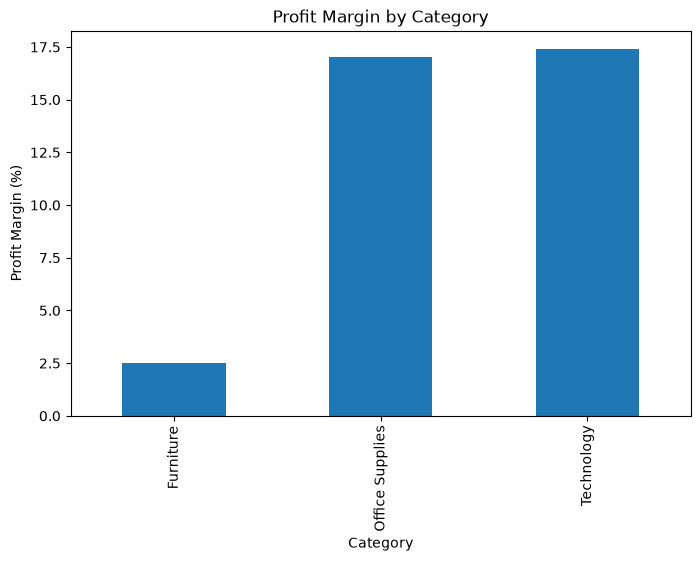

In [25]:
category_data['Profit_Margin'].plot(kind='bar', figsize=(8,5))
plt.title('Profit Margin by Category')
plt.xlabel('Category')
plt.ylabel('Profit Margin (%)')
plt.show()

## Observation
Technology has the highest profit margin at approximately 17.4%. Office Supplies is very close, with a margin of around 17.0%. Furniture has a substantially lower margin of only about 2.5%.

## Business Insights
Technology and Office Supplies show strong and comparable profit margins of around 17%, while Furniture has a significantly lower margin of approximately 2.5%. This indicates substantial variation in profitability across categories and highlights Furniture as an area requiring further analysis of pricing, discounts, costs, and product mix.

##  Question 6: Which regions have high sales but comparatively low profit?

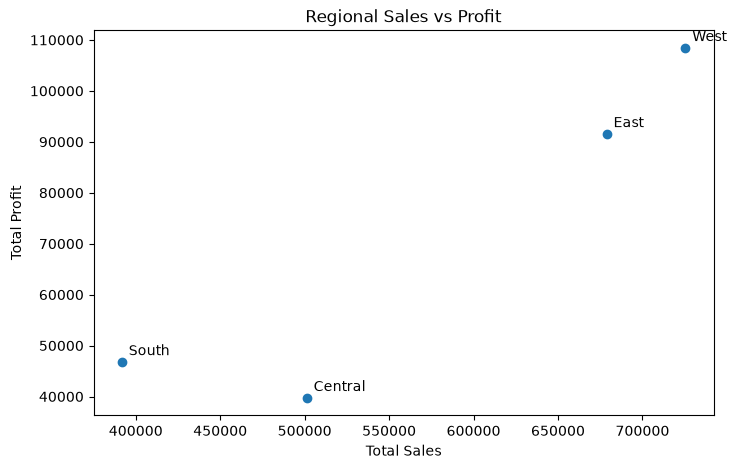

In [26]:
region_data = df.groupby('Region').agg({'Sales': 'sum','Profit': 'sum'})
plt.figure(figsize=(8,5))
plt.scatter(region_data['Sales'], region_data['Profit'])

for region, row in region_data.iterrows():
  plt.annotate(region,(row['Sales'], row['Profit']), xytext=(5, 5),textcoords='offset points')

plt.xlabel('Total Sales')
plt.ylabel('Total Profit')
plt.title('Regional Sales vs Profit')
plt.show()

## Observation
The West region has the highest total sales (≈725K) and highest total profit (≈108K). The East region follows with ≈680K in sales and ≈92K in profit. Central has higher sales than South but generates lower profit. South has the lowest sales but slightly higher profit than Central, indicating better profitability relative to its sales volume.

## Business Insights
West is the strongest contributor to overall sales and profit and can be examined for successful sales strategies. Central requires attention, as its relatively high sales do not translate into equally high profit. Pricing, discounts, costs, and product mix could be investigated. South's performance suggests that sales volume is not the only factor driving profit, making its product mix and pricing strategies worth examining. The overall pattern indicates that increasing sales generally contributes to higher total profit, but sales quality and profit margins also matter.

## Question 7: How does average discount vary across product categories?

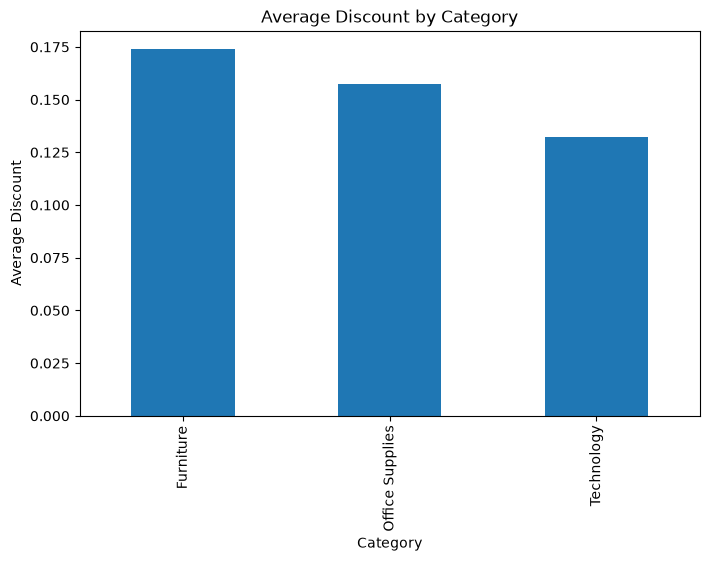

In [27]:
category_discount = df.groupby('Category')['Discount'].mean()
category_discount.plot(kind='bar', figsize=(8,5))
plt.title('Average Discount by Category')
plt.xlabel('Category')
plt.ylabel('Average Discount')
plt.show()

## Observations 
Furniture has the highest average discount at approximately 17.4%. Office Supplies follows with an average discount of around 15.7%. Technology has the lowest average discount at approximately 13.2%.

## Business Insights
Furniture has the highest average discount, indicating greater reliance on discounting compared with the other categories. Technology maintains lower discount levels, indicating that these products may sell with less reliance on price reductions. The differences in average discount levels indicate that discounting varies by category and may warrant further investigation.


## Question 8: Which customer segments generate the highest profit?

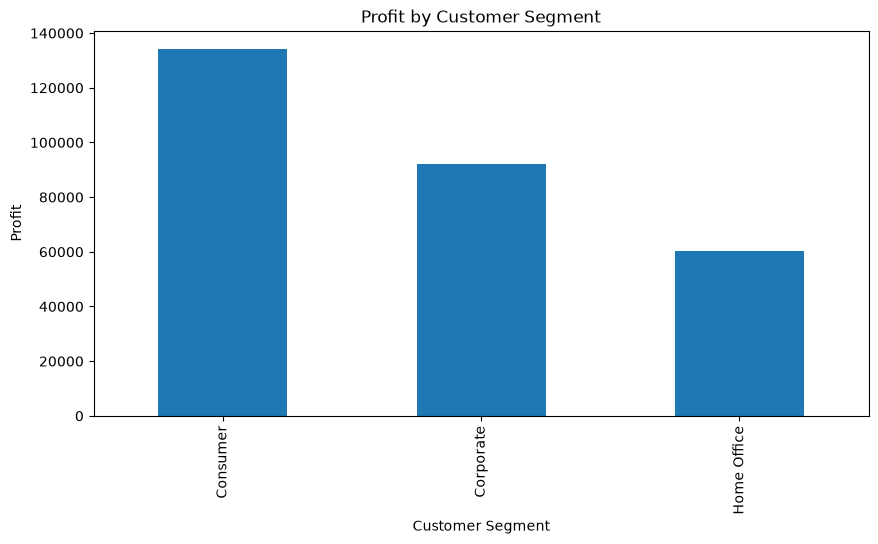

In [28]:
segment_profit= df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)
segment_profit.plot(kind= 'bar', figsize=(10,5))
plt.title('Profit by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Profit')
plt.show()          

## Observation
The Consumer segment generates the highest profit, followed by Corporate, while Home Office contributes the lowest profit.

## Business Insight
The Consumer segment is the strongest profit contributor, indicating an opportunity to maintain and expand this customer base. The Home Office segment may require targeted strategies to improve its profitability.

## 7. Key Insights

1. The **West and East regions** are the strongest contributors to total sales, while the South region records comparatively lower sales.
2. The **Consumer segment** contributes the largest share of sales and generates the highest total profit, making it an important contributor to overall business performance.
3. Sales are concentrated among key products, with **Phones and Chairs** among the leading products, while Fasteners, Labels, and Envelopes contribute comparatively lower sales.
4. Monthly sales show considerable fluctuations, with sales levels improving in the later years and a notable monthly peak occurring in 2017.
5. **Technology and Office Supplies** achieve strong profit margins of approximately 17%, while **Furniture has a substantially lower margin of around 2.5%**.
6. Regional analysis shows that higher sales generally contribute to higher total profit, but sales volume alone does not determine profitability. Central, for example, generates higher sales than South but lower profit.
7. **Furniture has the highest average discount**, while Technology has the lowest, highlighting differences in discounting practices across categories.
8. Overall, the analysis shows that **sales performance, profitability, product mix, customer segments, regional performance, and discount levels** should be considered together when evaluating business performance.


## 8. Conclusion

This project successfully transformed business sales data into meaningful visualizations using Python, Pandas, Matplotlib, and Seaborn. The analysis examined regional sales, customer segments, product performance, monthly sales trends, profitability, discounts, and customer-segment profit contribution.

The findings show that business performance varies across regions, products, categories, and customer segments. The West region and Consumer segment are major contributors to overall performance, while Furniture requires closer attention because of its comparatively low profit margin and higher average discount. The analysis also demonstrates that strong sales do not always result in proportionally strong profitability.

Overall, the visualizations provide a clear understanding of key business patterns and highlight areas for further investigation and data-driven decision-making. The project demonstrates how data visualization can transform raw business data into meaningful and actionable business insights.
